# BNJetTag, end to end

A walk through the code in `bnjettag/code/hgq2`, in the order it runs. Every cell
calls the functions the cluster jobs call — nothing here is a simplified
re-implementation, because a tutorial that drifts from the code teaches the wrong
thing with confidence.

**The claim being built.** A jet tagger for the CMS Level-1 trigger whose weights are
binary: `{-1, +1}` times one scale per tensor. A multiply by ±1 is a sign flip, and an
FPGA does sign flips in logic (LUTs) rather than in a DSP block. DSPs are the scarce
resource on a trigger board, so a binary core that uses none of them buys room for
everything else. What that costs in tagging accuracy is the question the project
exists to answer.

**Parts.** 0 the map · 1 data · 2 config · 3 the binarizer · 4 what HGQ2 is ·
5 why a stock 1-bit quantizer fails · 6 the STE that replaces it · 7 the model ·
8 activation quantization · 9 the binary gate · 10 train · 11 score · 12 what's next.

About two minutes end to end on a laptop CPU.

---
## Part 0 — the map

`bnhgq2` is nine modules that matter. This notebook imports six of them:

| module | what it owns | used in |
| --- | --- | --- |
| `config.py` | load / validate a config JSON, hash it | Part 2 |
| `data.py` | the eval loader, feature selection, input standardization | Parts 1, 11 |
| `binarize.py` | absmean binarization + the β-fold bookkeeping | Part 3 |
| `qat.py` | **the training model**: binary layers, quantizer configs, calibration | Parts 5–9 |
| `train.py` | the training loop, the train-split loader | Parts 1, 10 |
| `gold.py` | an independent numpy model, and the AUC helper | Part 11 |

The three it does *not* import, because they belong to the export half of the
pipeline: `build.py` (re-emits the trained model as a static hardware graph),
`convert.py` (hls4ml), `verify.py` (the three fidelity gates). Part 12 says where
those fit.

Everything below runs against whatever `PYTHONPATH` points at — there is one copy of
the pipeline code and this notebook does not carry its own.

In [1]:
import os, sys, json, glob, time, platform
import numpy as np

CODE = os.environ["PYTHONPATH"]
TRAIN_DIR = os.environ["BNHGQ2_TRAIN_DATA"]

print("python :", sys.version.split()[0], "|", platform.platform())
print("code   :", CODE)
print("train  :", TRAIN_DIR)
print("wandb  :", os.environ.get("WANDB_MODE"), "->", os.environ.get("WANDB_PROJECT"))

from bnhgq2 import config as bncfg, data as bndata, qat
from bnhgq2 import train as bntrain
from bnhgq2.binarize import absmean_binarize
from bnhgq2.gold import macro_ovr_auc, softmax64
import bnhgq2

print()
print("bnhgq2 loaded from:", os.path.dirname(bnhgq2.__file__))

python : 3.12.13 | macOS-26.5-arm64-arm-64bit
code   : /Users/kaiyamaguchi/Downloads/bnjettag-training-results/bnjettag/code/hgq2
train  : /Users/kaiyamaguchi/Downloads/bnjettag-training-results/data/train
wandb  : offline -> bnjettag-lab



bnhgq2 loaded from: /Users/kaiyamaguchi/Downloads/bnjettag-training-results/bnjettag/code/hgq2/bnhgq2


---
## Part 1 — the data

The public HLS4ML LHC Jet dataset (Zenodo record 3602260). Each `.h5` holds 10,000
jets. A *jet* is the spray of particles produced when a quark or gluon is knocked out
of a proton collision; the task is to say what started it. Five classes: gluon, light
quark, W boson, Z boson, top quark.

Each jet arrives as a list of up to 150 constituent particles with 16 features each.
`load_train_data` reduces that to what a trigger could actually receive, and three
things happen inside it that all matter downstream:

1. **sort by descending pT.** A particle list has no intrinsic order, so a canonical
   one is imposed — hardest particle first. Without this the model would have to
   learn to be permutation-invariant for free.
2. **truncate to `n_part`.** The trigger has a fixed input budget. This config keeps 8.
3. **select features, *after* the sort** — so the particle ordering is identical
   whichever features you choose. `["pt", "etarel", "phirel"]` is the L1-realistic
   set the field standardized on (Odagiu et al., arXiv:2402.01876): transverse
   momentum, and position relative to the jet axis.

In [2]:
X1, Y1, nfiles = bntrain.load_train_data(
    TRAIN_DIR, n_part=8, max_files=1, features=["pt", "etarel", "phirel"])

print(f"{nfiles} file -> X {X1.shape} {X1.dtype}, Y {Y1.shape}")
print("   (jets, constituents, features)      (jets, classes) one-hot")
print()
print("classes:", dict(zip(bndata.CLASS_NICE, Y1.sum(0).astype(int))))
print()
print("jet 0 -- its 8 hardest constituents (pt [GeV], etarel, phirel):")
print(np.round(X1[0], 4))
print()
print("this jet is a:", bndata.CLASS_NICE[int(Y1[0].argmax())])
print("pT descending within every jet:", bool(np.all(np.diff(X1[:, :, 0], axis=1) <= 1e-6)))

1 file -> X (10000, 8, 3) float32, Y (10000, 5)
   (jets, constituents, features)      (jets, classes) one-hot

classes: {'g': np.int64(2072), 'q': np.int64(1885), 'W': np.int64(2010), 'Z': np.int64(1931), 't': np.int64(2102)}

jet 0 -- its 8 hardest constituents (pt [GeV], etarel, phirel):
[[ 4.036696e+02 -6.000000e-03 -3.400000e-03]
 [ 1.378476e+02 -8.500000e-03  4.100000e-03]
 [ 5.531870e+01 -1.600000e-02 -2.350000e-02]
 [ 5.198290e+01 -1.650000e-02  8.000000e-04]
 [ 4.644300e+01 -3.500000e-03 -1.090000e-02]
 [ 4.440920e+01 -1.350000e-02 -1.590000e-02]
 [ 3.566340e+01 -1.640000e-02 -8.240000e-02]
 [ 3.452860e+01 -1.850000e-02 -5.900000e-03]]

this jet is a: g
pT descending within every jet: True


Note the scales: pT is hundreds of GeV while `etarel`/`phirel` are hundredths. A
network fed that raw would spend its early training just undoing the scale. `data.py`
provides `input_std_stats` / `apply_input_std` for a per-feature z-score computed on
the **train split only**, and the training run writes those statistics to
`input_std.json` beside the checkpoint. Part 11 has to reuse them, and Part 12
explains why the hardware does too.

---
## Part 2 — the config *is* the experiment

One JSON fully describes a model and its quantization. The pipeline reads
architecture and precision from nowhere else, so an experiment is reproducible by
quoting a filename. `cfg_hash` is an 8-hex fingerprint of the scientific content
(private keys excluded) — same hash, same experiment.

In [3]:
CONFIG = os.path.join(CODE, "configs", "r14-l1x3-n8-w1a8.json")
cfg = bncfg.load_config(CONFIG)
h = bncfg.cfg_hash(cfg)
A = cfg["arch"]

print(cfg["name"], "| hash", h, "| era", cfg["era"])
print()
for k, note in [("n_part", "constituents kept"), ("n_feat", "features per constituent"),
                ("d_model", "embedding width"), ("n_heads", "attention heads"),
                ("n_layers", "transformer blocks"), ("ffn_dim", "feed-forward width"),
                ("n_classes", "output classes"), ("pool", "how tokens are pooled"),
                ("norm", "normalization (none = the norm-free variant)")]:
    print(f"  arch.{k:10s} {str(A[k]):8s}  {note}")
print()
for k, v in cfg["quant"].items():
    print(f"  quant.{k:22s} {v}")

r14-l1x3-n8-w1a8 | hash 38a20c62 | era 2

  arch.n_part     8         constituents kept
  arch.n_feat     3         features per constituent
  arch.d_model    32        embedding width
  arch.n_heads    4         attention heads
  arch.n_layers   2         transformer blocks
  arch.ffn_dim    64        feed-forward width
  arch.n_classes  5         output classes
  arch.pool       gap       how tokens are pooled
  arch.norm       none      normalization (none = the norm-free variant)

  quant.weight                 binary_absmean
  quant.act_bits               8
  quant.act_policy             static_per_tensor_mse_calibrated
  quant.calib_n                8192
  quant.act_calib              trainable


`quant.weight = binary_absmean` is the thesis. `act_bits = 8` is how far the
*activations* are quantized — the second axis of the study. The round-14 grid is this
same architecture across both axes:

In [4]:
names = sorted(os.path.basename(p) for p in
               glob.glob(os.path.join(CODE, "configs", "r14-*.json")))
widths = sorted({n.split("-")[2] for n in names}, key=lambda s: int(s[1:]))
precs  = sorted({n.split("-")[3].removesuffix(".json") for n in names})
print("constituents :", widths)
print("precisions   :", precs)
print()
print(f"{len(names)} configs = {len(widths)} widths x {len(precs)} precisions")
print("w1 = binary weights (the thesis) | w8a8, fp32 = baselines | a8/a6/a4 = activation ladder")

constituents : ['n8', 'n16', 'n32', 'n64']
precisions   : ['fp32', 'w1a4', 'w1a6', 'w1a8', 'w8a8']

20 configs = 4 widths x 5 precisions
w1 = binary weights (the thesis) | w8a8, fp32 = baselines | a8/a6/a4 = activation ladder


---
## Part 3 — the binarizer, on eight numbers you can check by hand

`binarize.absmean_binarize` is the whole idea, and it is four lines of numpy
(BitNet, arXiv:2310.11453):

```
alpha = mean(W)          # centre the tensor
Wc    = W - alpha
beta  = mean(|Wc|)       # one scale for the whole tensor
q     = sign(Wc)         # one bit per weight
```

The stored weight is `q * beta`. `n_zero` **must** be 0: a weight of exactly zero
would be a third state, and binary hardware has no third state, so the pipeline
treats any zero as a stop condition rather than rounding it away.

In [5]:
W = np.array([[-0.9, 0.2, 0.5, -0.1],
              [ 0.3, 0.8, -0.4, 0.05]], dtype=np.float32)
q, beta, alpha, n_zero = absmean_binarize(W)

print("W      =\n", W)
print()
print("alpha  =", round(alpha, 6), "   mean(W)")
print("beta   =", round(beta, 6), "   mean(|W - alpha|) + 1e-6")
print("q      =\n", q)
print("n_zero =", n_zero, "  <- must be 0")
print()
print("effective weight q*beta =\n", np.round(q * beta, 6))
print("distinct values:", np.unique(np.round(q * beta, 10)))
print()
print("compression: 32 bits/weight ->", f"1 bit/weight + one {beta:.6f} per tensor")

W      =
 [[-0.9   0.2   0.5  -0.1 ]
 [ 0.3   0.8  -0.4   0.05]]

alpha  = 0.05625    mean(W)
beta   = 0.393751    mean(|W - alpha|) + 1e-6
q      =
 [[-1  1  1 -1]
 [ 1  1 -1 -1]]
n_zero = 0   <- must be 0

effective weight q*beta =
 [[-0.393751  0.393751  0.393751 -0.393751]
 [ 0.393751  0.393751 -0.393751 -0.393751]]
distinct values: [-0.393751  0.393751]

compression: 32 bits/weight -> 1 bit/weight + one 0.393751 per tensor


---
## Part 4 — what HGQ2 actually is

HGQ2 (`import hgq`) is the quantization-aware-training library this project builds
on. Its unit is the **quantizer config**: a description of a fixed-point grid, which
gets attached to a layer's weights, its inputs, or its bias.

A `QuantizerConfig` answers four questions:

| field | means |
| --- | --- |
| `q_type` | how the grid is parametrized — `kif` (keep/integer/fractional bits) or `kbi` (keep/**b**its-total/integer) |
| `place` | what it quantizes: `weight`, `datalane` (activations), `bias`, `table` |
| `round_mode` | what happens between grid points — `RND`, `RND_CONV` (round-half-to-even) |
| `overflow_mode` | what happens outside the range — `SAT` (clip), `SAT_SYM`, `WRAP` |

`kif` vs `kbi` looks like a detail and is the hinge of two different experiments.
`kif` carries integer bits `i` and fractional bits `f` independently, so the total
width is whatever they add to. `kbi` carries a **total** width `b` and the integer
split `i`, deriving `f = b - i`. If you want to pin a width at 4 bits and let the
model slide the binary point around during training, you need `kbi` — you constrain
`b` and leave `i` free. That is exactly `qat._trainable_act`.

Here is a quantizer on its own, with no model around it:

In [6]:
import keras
from hgq.quantizer import Quantizer, QuantizerConfig

def grid_of(bits, i, x):
    """Push x through a signed fixed<bits, 1+i> datalane grid and return it."""
    c = QuantizerConfig("kif", "datalane", k0=1, i0=i, f0=bits - 1 - i,
                        round_mode="RND_CONV", overflow_mode="SAT",
                        trainable=False, heterogeneous_axis=())
    qz = Quantizer(c); qz.build(x.shape)
    return np.asarray(keras.ops.convert_to_numpy(qz(keras.ops.convert_to_tensor(x))))

x = np.linspace(-3, 3, 2001, dtype="float32")
grids = {}
for bits, i in [(8, 2), (4, 2), (4, 0)]:
    y = grid_of(bits, i, x)
    u = np.unique(y)
    grids[(bits, i)] = (float(np.diff(u).min()), float(u.min()), float(u.max()))
    print(f"fixed<{bits},1+{i}>  f={bits - 1 - i}  levels={len(u):4d}  "
          f"step={grids[(bits, i)][0]:.5f}  "
          f"reaches [{u.min():+.3f}, {u.max():+.3f}]")

print()
print("The step is 2^-f and the reach is +/-2^i, so at a FIXED width the two trade:")
for (bits, i), (step, lo, hi) in grids.items():
    print(f"  fixed<{bits},1+{i}>: step {step:g}, reach {hi:+g}")
s8, s4 = grids[(8, 2)][0], grids[(4, 2)][0]
print()
print(f"Same i, half the bits: step went {s8:g} -> {s4:g} ({s4 / s8:.0f}x coarser).")
r2, r0 = grids[(4, 2)][2], grids[(4, 0)][2]
t2, t0 = grids[(4, 2)][0], grids[(4, 0)][0]
print(f"Same width, i 2 -> 0: reach {r2:+g} -> {r0:+g}, but step {t2:g} -> {t0:g}.")
print()
print("(The 8-bit row saturates at the input's own +/-3, not at its 2^i=4 limit.)")
print("Choosing i per tensor is what 'calibration' means -- see Part 8.")

fixed<8,1+2>  f=5  levels= 193  step=0.03125  reaches [-3.000, +3.000]
fixed<4,1+2>  f=1  levels=  13  step=0.50000  reaches [-3.000, +3.000]
fixed<4,1+0>  f=3  levels=  16  step=0.12500  reaches [-1.000, +0.875]

The step is 2^-f and the reach is +/-2^i, so at a FIXED width the two trade:
  fixed<8,1+2>: step 0.03125, reach +3
  fixed<4,1+2>: step 0.5, reach +3
  fixed<4,1+0>: step 0.125, reach +0.875

Same i, half the bits: step went 0.03125 -> 0.5 (16x coarser).
Same width, i 2 -> 0: reach +3 -> +0.875, but step 0.5 -> 0.125.

(The 8-bit row saturates at the input's own +/-3, not at its 2^i=4 limit.)
Choosing i per tensor is what 'calibration' means -- see Part 8.


---
## Part 5 — why the stock quantizer cannot do binary

The obvious way to get binary weights out of HGQ2 is to ask for a 1-bit weight
quantizer: `kbi`, `b=1`, `i=1`, symmetric saturation. It does not work, and the
reason is worth seeing rather than being told.

A 1-bit *fixed-point* grid is not `{-1, +1}`. Fixed point is a uniform grid that
**includes zero** — with one bit plus a sign you get `{-1, 0, +1}`. That is ternary.
And since it rounds each latent weight to the nearest grid point, small weights do
not become ±1: they become 0.

The module docstring in `qat.py` records this as probe T1 — 4096 of 4096 latents went
to zero. Reproduce it:

In [7]:
latents = np.random.default_rng(0).normal(0, 0.05, size=(64, 64)).astype("float32")

kbi1 = QuantizerConfig("kbi", "weight", k0=1, b0=1, i0=1,
                       round_mode="RND", overflow_mode="SAT_SYM",
                       trainable=False, heterogeneous_axis=())
qz = Quantizer(kbi1); qz.build(latents.shape)
stock = np.asarray(keras.ops.convert_to_numpy(qz(keras.ops.convert_to_tensor(latents))))

print("stock HGQ2 1-bit weight quantizer, on 4096 realistic latents")
print("  distinct output values :", np.unique(stock))
print("  exact zeros            :", int((stock == 0).sum()), "of", stock.size)
print()
print("  -> not binary. Every weight was annihilated.")
print()
print("the project's binarizer, same tensor:")
q2, beta2, _, nz2 = absmean_binarize(latents)
print("  distinct output values :", np.unique(np.round(q2 * beta2, 10)))
print("  exact zeros            :", nz2)

stock HGQ2 1-bit weight quantizer, on 4096 realistic latents
  distinct output values : [0.]
  exact zeros            : 4096 of 4096

  -> not binary. Every weight was annihilated.

the project's binarizer, same tensor:
  distinct output values : [-0.04006949  0.04006949]
  exact zeros            : 0


This is why `qat.py` defines its own weight path instead of configuring one. The
layers `BitQEinsumDense` / `BitQDense` subclass HGQ2's `QEinsumDense` / `QDense` and
replace one line of `call()` — the kernel is binarized in the forward pass by
`bitnet_binary_ste` instead of being passed through a fixed-point quantizer.

The layers still carry a 1-bit `kq_conf` (`qat._binary_kq`). Not for arithmetic —
purely so that EBOPs accounting and hls4ml *report* one bit for the weights, which
they must, because one bit is what the hardware will store.

---
## Part 6 — the straight-through estimator

Binarizing in the forward pass creates a training problem: `sign` has zero gradient
almost everywhere, so nothing upstream would ever learn. The straight-through
estimator is the standard answer — use the binarized value going forward, but pretend
the binarization was the identity going backward.

In `qat.bitnet_binary_ste` that is the line `wq = ws + stop_gradient(q - ws)`. Forward
it equals `q`; backward the `stop_gradient` term vanishes and the gradient flows
through `ws` to the latent float weight, which is what actually gets updated. The
binary weights are never stored during training — they are recomputed from the
latents on every forward pass.

Two deliberate departures from the QKeras reference are documented at `qat.py:43`: a
strict bipolar sign so a tie goes to `+1` and never to `0`, and a bounded backward
that removed a NaN observed at 4-bit activations.

In [8]:
lat = keras.ops.convert_to_tensor(latents)
ste = np.asarray(keras.ops.convert_to_numpy(qat.bitnet_binary_ste(lat)))

print("forward output of the STE:")
print("  distinct values :", np.unique(np.round(ste, 8)))
print("  matches the numpy binarizer:",
      bool(np.allclose(ste, q2 * beta2, atol=1e-7)))
print()
print("The training graph and the export path run the SAME arithmetic --")
print("that is why the exported hardware model reproduces the trained one.")

forward output of the STE:
  distinct values : [-0.04006948  0.04006948]
  matches the numpy binarizer: True

The training graph and the export path run the SAME arithmetic --
that is why the exported hardware model reproduces the trained one.


---
## Part 7 — the model

`build_qat_model(cfg, seed)` returns `(model, taps)`. It is a small transformer
encoder: project each constituent to `d_model`, add a learned positional encoding,
run `n_layers` attention+FFN blocks, average over the constituents, classify.

`taps` is the second return value and easy to overlook — it is a dict of
*pre-quantization* tensors, one per activation site, kept so that Part 8 can measure
the real distribution flowing into each quantizer.

In [9]:
model, taps = qat.build_qat_model(cfg, seed=1)

print("total parameters    :", f"{model.count_params():,}")
print("trainable parameters:", f"{sum(int(np.prod(v.shape)) for v in model.trainable_variables):,}")
print("activation tap sites:", len(taps))
print()
kinds = {}
for ly in model.layers:
    kinds[type(ly).__name__] = kinds.get(type(ly).__name__, 0) + 1
for k, v in sorted(kinds.items(), key=lambda kv: -kv[1]):
    print(f"  {v:3d}  {k}")

total parameters    : 18,657
trainable parameters: 18,511
activation tap sites: 19

   13  BitQEinsumDense
    4  QEinsum
    4  Add
    3  ReLU
    2  QSoftmax
    2  BitQDense
    1  InputLayer
    1  AddPositional
    1  QGlobalAveragePooling1D


The names are not decoration — `build.py` and `port.py` match layers by name when the
trained model is re-emitted for hardware, so the graph below is also the export map.

In [10]:
for ly in model.layers[:14]:
    shp = tuple(ly.output.shape) if hasattr(ly, "output") else None
    star = " *" if type(ly).__name__.startswith("Bit") else "  "
    print(f"{star} {ly.name:28s} {type(ly).__name__:26s} {shp}")
print("   ... block 1 repeats, then:")
for ly in model.layers[-4:]:
    shp = tuple(ly.output.shape) if hasattr(ly, "output") else None
    star = " *" if type(ly).__name__.startswith("Bit") else "  "
    print(f"{star} {ly.name:28s} {type(ly).__name__:26s} {shp}")
print()
print("* = binary-weight layer")

   input_1                      InputLayer                 (None, 8, 3)
 * input_proj                   BitQEinsumDense            (None, 8, 32)
   pos_enc                      AddPositional              (None, 8, 32)
 * bit_block_0_attn_Wq          BitQEinsumDense            (None, 8, 4, 8)
 * bit_block_0_attn_Wk          BitQEinsumDense            (None, 8, 4, 8)
   bit_block_0_attn_scores      QEinsum                    (None, 4, 8, 8)
   bit_block_0_attn_softmax     QSoftmax                   (None, 4, 8, 8)
 * bit_block_0_attn_Wv          BitQEinsumDense            (None, 8, 4, 8)
   bit_block_0_attn_ctx         QEinsum                    (None, 8, 4, 8)
 * bit_block_0_attn_Wo          BitQEinsumDense            (None, 8, 32)
   bit_block_0_add_attn         Add                        (None, 8, 32)
 * bit_block_0_ffn_fc1          BitQEinsumDense            (None, 8, 64)
   bit_block_0_ffn_act          ReLU                       (None, 8, 64)
 * bit_block_0_ffn_fc2          BitQEins

Reading one block: `Wq`/`Wk` produce queries and keys, `scores` is their einsum,
`softmax` normalizes it, `Wv` produces values, `ctx` mixes them, `Wo` projects back,
and `add_attn` is the residual. Then `fc1 -> ReLU -> fc2` and a second residual. All
six matmuls in the block are binary; the softmax and the two einsums are not — they
have no weights.

`arch.norm = "none"` in this config means the LayerNorms are identity passthroughs.
That is the norm-free variant: no parameters, no DSPs, and (per `binarize.py`) it
changes how every β must be handled at export, because there is no normalization
downstream to absorb a scale.

---
## Part 8 — activation quantization and calibration

Weights are only half of it. Every tensor flowing between layers also has to land on
a fixed-point grid, and each site needs its own integer/fractional split: attention
scores, ReLU outputs and pooled embeddings do not share a range.

`calibrate_activations` picks that split from data. For each tap it tries every legal
integer-bit count and keeps the one with the lowest mean-squared error against the
unquantized tensor. The docstring records why MSE rather than max-plus-margin: at 4
bits, range-based calibration leaves zero fractional bits — an integer-only grid that
flattens the signal.

In [11]:
before = qat.act_grid_params(model)
site_i = qat.calibrate_activations(model, taps, X1[:4096], int(cfg["quant"]["act_bits"]))
after = qat.act_grid_params(model)

ab = int(cfg["quant"]["act_bits"])
print(f"calibrated {len(site_i)} sites at {ab} bits (i = integer bits, f = {ab}-1-i)\n")
print(f"  {'site':30s} {'i before':>9s} {'i after':>8s}")
moved = 0
for k in list(site_i)[:8]:
    b_i = before.get(k, ("-", "-"))[0]
    a_i = after.get(k, ("-", "-"))[0]
    moved += (b_i != a_i)
    print(f"  {k:30s} {str(b_i):>9s} {str(a_i):>8s}")
print("  ...")
print()
print("distinct integer-bit choices across all sites:", sorted(set(site_i.values())))
print("-> the sites genuinely disagree; one global grid would be wrong for most of them.")

calibrated 19 sites at 8 bits (i = integer bits, f = 8-1-i)

  site                            i before  i after
  input_proj                           4.0      6.0
  bit_block_0_attn_Wq                  4.0      2.0
  bit_block_0_attn_Wk                  4.0      2.0
  bit_block_0_attn_Wv                  4.0      2.0
  bit_block_0_attn_scores__in0         6.0      3.0
  bit_block_0_attn_scores__in1         6.0      3.0
  bit_block_0_attn_Wo                  4.0      3.0
  bit_block_0_ffn_fc1                  4.0      4.0
  ...

distinct integer-bit choices across all sites: [2, 3, 4, 5, 6]
-> the sites genuinely disagree; one global grid would be wrong for most of them.


`act_calib` in the config decides what happens next. `frozen` keeps this grid for the
whole run. `trainable` (used here) pins the *width* with a constraint and lets the
integer split keep training, so the grid follows the activations as they drift — the
rescue for 4-bit, where a first-batch grid was measured to stall. `free` lets the
width itself train under an EBOPs penalty, which is a different experiment entirely.

---
## Part 9 — the gate that enforces the claim

A model is only binary if its effective forward weights really are two values,
symmetric about zero, with nothing between. `effective_weight_values` runs the
binarizer over every bit-layer and reports what it finds; `train.py` asserts on this
before a single epoch runs. If it ever failed the headline claim would be void, so it
is checked rather than assumed.

In [12]:
effs = qat.effective_weight_values(model)
print(f"{len(effs)} binary layers\n")
for name, vals in list(effs.items())[:5]:
    print(f"  {name:28s} {np.round(vals, 6)}   beta = {vals[1]:.6f}")
print("  ...")
print()
two_valued = all(len(v) == 2 for v in effs.values())
symmetric  = all(len(v) == 2 and abs(v[0] + v[1]) < 1e-12 for v in effs.values())
no_zero    = all(not (v == 0).any() for v in effs.values())
print("exactly two values per layer :", two_valued)
print("symmetric about zero         :", symmetric)
print("no zero state                :", no_zero)
assert two_valued and symmetric and no_zero, "BINARY GATE FAILED"
print("\nbinary gate OK -- every layer is {-beta, +beta}")
print("note each layer has its OWN beta: one float per tensor, not one for the model.")

15 binary layers

  input_proj                   [-0.200141  0.200141]   beta = 0.200141
  bit_block_0_attn_Wq          [-0.155241  0.155241]   beta = 0.155241
  bit_block_0_attn_Wk          [-0.158338  0.158338]   beta = 0.158338
  bit_block_0_attn_Wv          [-0.154077  0.154077]   beta = 0.154077
  bit_block_0_attn_Wo          [-0.1538  0.1538]   beta = 0.153800
  ...

exactly two values per layer : True
symmetric about zero         : True
no zero state                : True

binary gate OK -- every layer is {-beta, +beta}
note each layer has its OWN beta: one float per tensor, not one for the model.


---
## Part 10 — train it

`smoke=True` is the project's small-sample switch: 3 epochs over 2 files, no warmup.
It runs the *same* code path as a real job rather than a separate reduced one — a
shortcut that skips code cannot tell you the code works.

`train` builds its own model internally (the one above was for inspection), runs the
calibration pass, asserts the binary gate, trains, and writes `model_best.keras`,
`train_meta.json` and `input_std.json`.

In [13]:
OUT = os.path.join(os.environ["BNHGQ2_OUT_ROOT"], "tutorial-" + cfg["name"])
t0 = time.time()
meta = bntrain.train(cfg, seed=1, out_dir=OUT, smoke=True, cfg_hash=h)
print(f"\nwall clock: {time.time() - t0:.0f} s")

[train] L1-realistic feature subset: ['pt', 'etarel', 'phirel']


[train] data: 2 files, 20000 jets (16000 train / 4000 val), class counts [4141, 3852, 4019, 3909, 4079]


[train] input_std ON: per-feature z-score from train split (|mu|max=89.57, sigma_max=85.18) -> input_std.json


[train] r14-l1x3-n8-w1a8 params=18,657 trainable=18,511 act_sites=19 act_calib=trainable


[train] binary gate OK (15 bit-layers exactly +/-beta)


...

[wandb] artifact model-tutorial-r14-l1x3-n8-w1a8 staged (offline mode — no commit check)


wandb: 
wandb: Run history:
wandb: categorical_accuracy ▁▆█
wandb:                epoch ▁▅█
wandb:                 loss █▂▁
wandb:            val_auc_0 ▁██
wandb:            val_auc_1 ▁██
wandb:            val_auc_2 █▁▁
wandb:            val_auc_3 █▁▁
wandb:            val_auc_4 ▁██
wandb:        val_macro_auc ▁██
wandb: 
wandb: Run summary:
wandb:           best_epoch 1
wandb:   best_val_macro_auc 0.52871
wandb: categorical_accuracy 0.26669
wandb:                epoch 2
wandb:                 loss 1.60539
wandb:            val_auc_0 0.61127
wandb:            val_auc_1 0.42128
wandb:            val_auc_2 0.52421
wandb:            val_auc_3 0.4967
wandb:            val_auc_4 0.59007
wandb:                   +1 ...
wandb: 


wandb: You can sync this run to the cloud by running:
wandb: wandb sync /Users/kaiyamaguchi/Desktop/bnjettag-lab/local/wandb/wandb/offline-run-20260908_154659-bivgtqaw


wandb: Find logs at: /Users/kaiyamaguchi/Desktop/bnjettag-lab/local/wandb/wandb/offline-run-20260908_154659-bivgtqaw/logs



wall clock: 15 s


---
## Part 11 — score it on data it has never seen

Trained on the train split, evaluated on `data/val`. Two things are easy to get wrong
and both silently ruin the number:

- the model was trained on **standardized** inputs, so val must be standardized with
  the *same* mu/sigma — which is why the run wrote them to `input_std.json`;
- loading the checkpoint needs `bnhgq2.qat` **imported** first, or Keras cannot find
  `BitQEinsumDense`. Importing the package is not enough: the
  `@register_keras_serializable` decorators live in the module, and `__init__.py`
  does not import it.

In [14]:
VAL_DIR = os.path.join(bncfg.PROJECT_ROOT, "data", "val")
assert os.path.isdir(VAL_DIR), f"no val split at {VAL_DIR}"

Xv, Yv, nv = bntrain.load_train_data(
    VAL_DIR, n_part=A["n_part"], max_files=3, features=A["features"])

std = json.load(open(os.path.join(OUT, "input_std.json")))
Xv = bndata.apply_input_std(Xv, np.array(std["mu"], "float32"),
                            np.array(std["sigma"], "float32"))
print(f"val: {nv} files, {len(Xv)} jets, never seen in training")

best = keras.saving.load_model(os.path.join(OUT, "model_best.keras"))
logits = np.concatenate([np.asarray(best(Xv[i:i + 4096], training=False))
                         for i in range(0, len(Xv), 4096)])
scores = softmax64(logits).astype("float32")

auc, per_class = macro_ovr_auc(Yv, scores)
print(f"\nmacro-OvR AUC {auc:.4f}")
for c, a in zip(bndata.CLASS_NICE, per_class):
    print(f"  {c}  {a:.4f}")
print("\n*** 3 epochs on 16,000 jets. A SMOKE number, not a result. ***")

val: 3 files, 30000 jets, never seen in training



macro-OvR AUC 0.5359
  g  0.6107
  q  0.4330
  W  0.5300
  Z  0.5099
  t  0.5956

*** 3 epochs on 16,000 jets. A SMOKE number, not a result. ***


Read the per-class column, not just the average. A class scoring *below* 0.5 is not
simply "undertrained" — undertraining pulls a score toward 0.5, not past it. Below
chance means the model learned that class **backwards**: anti-correlated, systematically
confusing it with something else.

Expect to see that for `q`, with `g` scoring highest. Light-quark and gluon jets are
the notoriously hard pair — they differ only in subtle radiation patterns — and three
epochs is enough to latch onto the q/g axis while still having its sign wrong. A good
illustration of why a macro average can hide what a model is doing.

### the ROC, drawn the way the field draws it

Signal efficiency against background rejection `1/mistag`, log vertical axis. The log
axis is not decoration: a trigger operates at a mistag rate of `1e-3` or below, so the
part of the curve anyone cares about is crushed into the left edge of a linear plot.

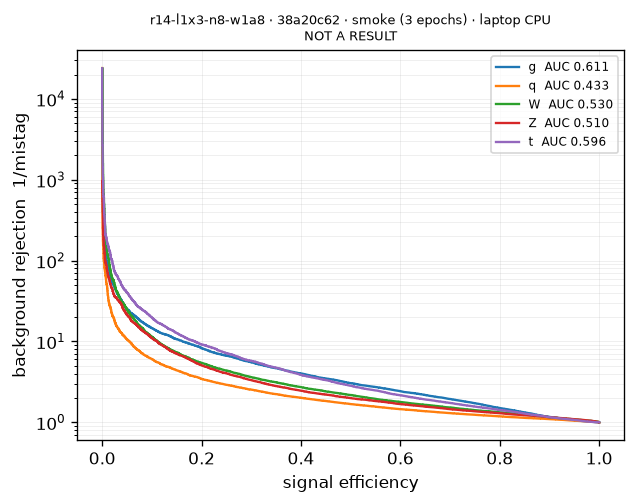

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(5.4, 4.3), dpi=120)
for c, nice in enumerate(bndata.CLASS_NICE):
    fpr, tpr, _ = roc_curve(Yv[:, c], scores[:, c])
    keep = fpr > 0
    ax.plot(tpr[keep], 1.0 / fpr[keep], lw=1.4, label=f"{nice}  AUC {per_class[c]:.3f}")

ax.set_yscale("log")
ax.set_xlabel("signal efficiency")
ax.set_ylabel("background rejection  1/mistag")
ax.set_title(f"{cfg['name']} · {h} · smoke (3 epochs) · laptop CPU\nNOT A RESULT",
             fontsize=8)
ax.grid(alpha=0.3, which="both", lw=0.4)
ax.legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()

---
## Part 12 — where this stops

`run_stage.py` runs the pipeline as stages. This notebook has walked the first one.

```
train  ->  extract  ->  calibrate  ->  build  ->  verify  ->  ebops  ->  convert
```

- **extract** reads the trained latent kernels out by layer name.
- **calibrate** fixes the final static activation grids.
- **build** (`build.py`) re-emits the model as a static hardware graph: the latents
  are re-binarized with the *same* `absmean_binarize` from Part 3, and each β is
  disposed of according to the fold table in `binarize.py` — folded into a bias,
  into the attention score scale, absorbed by a downstream LayerNorm, or kept as an
  explicit affine when it reaches a residual or the logits.
- **verify** (`verify.py`) runs three fidelity gates: the rebuilt model against the
  stored reference scores, the Keras forward against an independent numpy
  implementation in `gold.py` (same math, so any disagreement is a build bug), and
  the hls4ml C-simulation against Keras — which is required to be **bit-exact**,
  `max |delta| == 0`.
- **ebops** estimates the bit-operation cost.
- **convert** (`convert.py`) emits HLS, and C-synthesis runs on `mulder`
  (Vitis 2023.2, VU13P) to produce the LUT/FF/DSP/BRAM and latency tables — the
  numbers that carry the "0 DSP in the binary core" claim.

**None of that runs on a laptop, and nothing above is quotable.** This is a scratch
environment, drifted from the cluster's on at least one pin. Every number that reaches
`RESEARCH.md` or a report comes from a cluster Job and is recomputed from the stored
`.npz` arrays through the `verify-roc` skill. What this notebook is for is
understanding the code, and checking that it still runs.